In [2]:
%pip install nibabel scipy matplotlib pandas numpy torch

   ---------------------------------------- 0.0/3.3 MB ? eta -:--:--
   --- ------------------------------------ 0.3/3.3 MB ? eta -:--:--
   ------------ --------------------------- 1.0/3.3 MB 3.6 MB/s eta 0:00:01
   ---------------------- ----------------- 1.8/3.3 MB 4.0 MB/s eta 0:00:01
   ------------------------- -------------- 2.1/3.3 MB 3.0 MB/s eta 0:00:01
   ---------------------------------------- 3.3/3.3 MB 4.0 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: C:\Users\LENOVO\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


PROJECT_ROOT: C:\Users\LENOVO\Desktop\3D-Lung-Lesion-Segmentation
ANNOT_DIR: C:\Users\LENOVO\Desktop\3D-Lung-Lesion-Segmentation\data\mela\annotations
IMG_DIR: C:\Users\LENOVO\Desktop\3D-Lung-Lesion-Segmentation\data\mela\images
MODEL_PATH: C:\Users\LENOVO\Desktop\3D-Lung-Lesion-Segmentation\data\nsclc\models\best_model.pt
MODEL EXISTS: True
DEVICE: cpu
✅ Model loaded successfully
Annotations shape: (884, 7)
Spacing shape: (880, 7)
Annotation columns: ['public_id', 'coordX', 'coordY', 'coordZ', 'x_length', 'y_length', 'z_length']
Spacing columns: ['public_id', 'origin_x', 'origin_y', 'origin_z', 'spacing_x', 'spacing_y', 'spacing_z']
Merged dataframe shape: (884, 13)


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_23320\3169453477.py:113: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(MODEL_PATH, map_location=device)


,public_id,coordX,coordY,coordZ,x_length,y_length,z_length,origin_x,origin_y,origin_z,spacing_x,spacing_y,spacing_z
0,mela_0001,300,153,278,62,61,37,-162.130005,15.700000,-394.970001,0.605469,0.605469,1.000000
1,mela_0002,265,182,274,42,39,38,-181.210083,-185.636719,-507.846436,0.726562,0.726562,1.000000
2,mela_0003,259,269,315,111,81,100,-157.666016,-357.166016,-226.100006,0.667969,0.667969,0.700012
3,mela_0004,317,309,360,112,115,138,-199.605469,-351.605469,-376.899994,0.789062,0.789062,0.699982
4,mela_0005,284,187,345,40,59,54,-179.621094,-343.621094,167.600006,0.757812,0.757812,0.699997


public_id    mela_0001
coordX             300
coordY             153
coordZ             278
x_length            62
y_length            61
z_length            37
Name: 0, dtype: object
Status: ok
public_id: mela_0001
split: train
volume_shape: (385, 512, 512)
roi_shape: (56, 80, 82)
pred_sum: 11271
nonzero_slice_count: 31


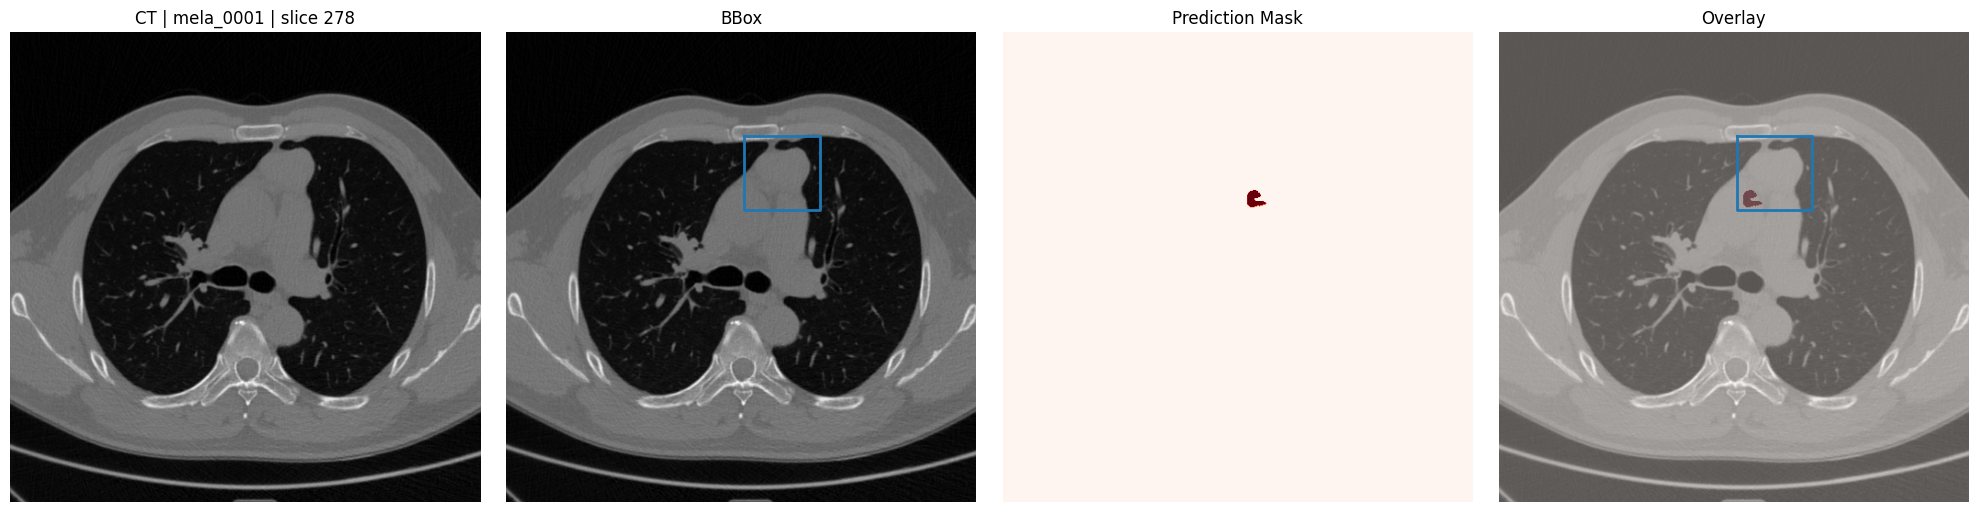

Nonzero slices: [257, 258, 259, 260, 261, 262, 263, 264, 265, 266, 267, 268, 269, 270, 271, 272, 273, 274, 275, 276] ... total: 31


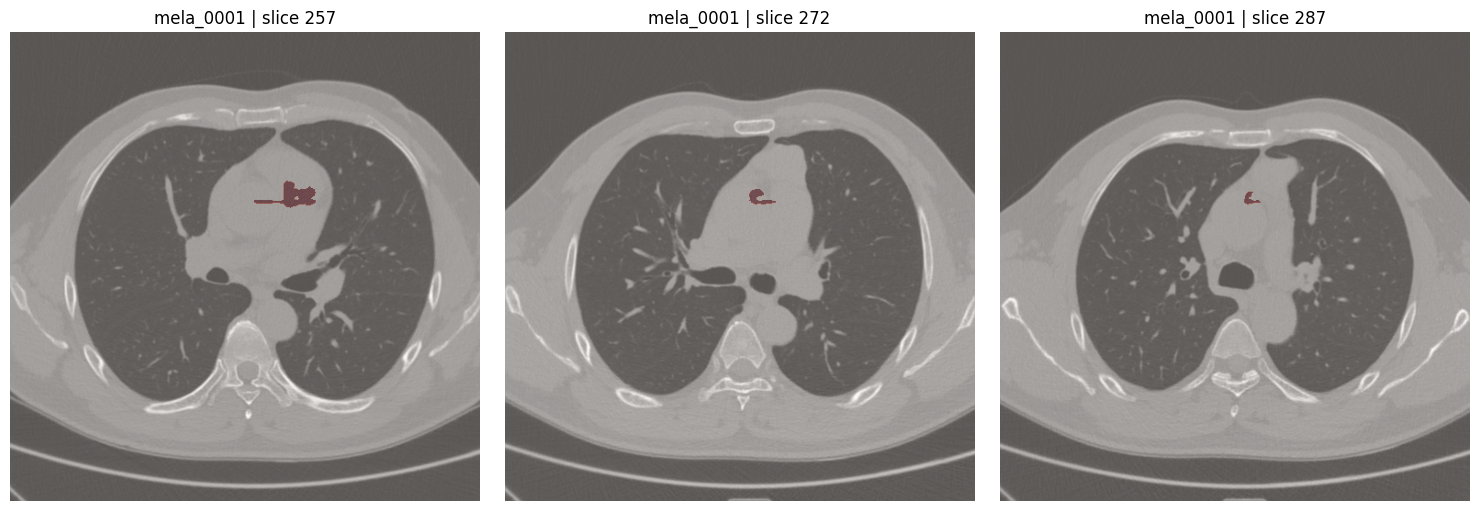

Saved prediction: C:\Users\LENOVO\Desktop\3D-Lung-Lesion-Segmentation\results\mela_single_case_predictions\mela_0001_pred.npy


In [3]:
# ============================================================
# 0) IMPORTS
# ============================================================
from pathlib import Path
import os
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
import scipy.ndimage as ndi
import torch
import torch.nn as nn


# ============================================================
# 1) PATHS
# KENDİ PROJE YOLUNA GÖRE GEREKİRSE DÜZENLE
# ============================================================
PROJECT_ROOT = Path(r"C:\Users\LENOVO\Desktop\3D-Lung-Lesion-Segmentation")

DATA_DIR = PROJECT_ROOT / "data"
RESULTS_DIR = PROJECT_ROOT / "results"

MELA_DIR = DATA_DIR / "mela"
NSCLC_DIR = DATA_DIR / "nsclc"

ANNOT_DIR = MELA_DIR / "annotations"
IMG_DIR = MELA_DIR / "images"
MELA_MASK_DIR = MELA_DIR / "masks"

NSCLC_MODEL_DIR = NSCLC_DIR / "models"
MODEL_PATH = NSCLC_MODEL_DIR / "best_model.pt"

SAVE_DIR = RESULTS_DIR / "mela_single_case_predictions"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

device = "cuda" if torch.cuda.is_available() else "cpu"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("ANNOT_DIR:", ANNOT_DIR)
print("IMG_DIR:", IMG_DIR)
print("MODEL_PATH:", MODEL_PATH)
print("MODEL EXISTS:", MODEL_PATH.exists())
print("DEVICE:", device)


# ============================================================
# 2) MODEL CLASS
# EĞİTİMDE KULLANDIĞIN MODELLE BİREBİR AYNI OLMALI
# ============================================================
class SimpleUNet(nn.Module):
    def __init__(self):
        super().__init__()

        def CBR(in_ch, out_ch):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True)
            )

        self.enc1 = nn.Sequential(CBR(1, 32), CBR(32, 32))
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = nn.Sequential(CBR(32, 64), CBR(64, 64))
        self.pool2 = nn.MaxPool2d(2)

        self.enc3 = nn.Sequential(CBR(64, 128), CBR(128, 128))
        self.pool3 = nn.MaxPool2d(2)

        self.bottleneck = nn.Sequential(CBR(128, 256), CBR(256, 256))

        self.up3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec3 = nn.Sequential(CBR(256, 128), CBR(128, 128))

        self.up2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec2 = nn.Sequential(CBR(128, 64), CBR(64, 64))

        self.up1 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.dec1 = nn.Sequential(CBR(64, 32), CBR(32, 32))

        self.out = nn.Conv2d(32, 1, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        p1 = self.pool1(e1)

        e2 = self.enc2(p1)
        p2 = self.pool2(e2)

        e3 = self.enc3(p2)
        p3 = self.pool3(e3)

        b = self.bottleneck(p3)

        u3 = self.up3(b)
        d3 = self.dec3(torch.cat([u3, e3], dim=1))

        u2 = self.up2(d3)
        d2 = self.dec2(torch.cat([u2, e2], dim=1))

        u1 = self.up1(d2)
        d1 = self.dec1(torch.cat([u1, e1], dim=1))

        out = self.out(d1)
        return out


# ============================================================
# 3) LOAD MODEL
# ============================================================
model = SimpleUNet().to(device)
state_dict = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(state_dict)
model.eval()

print("✅ Model loaded successfully")

# ============================================================
# 4) LOAD MELA TABLES
# ============================================================
ann_df = pd.read_csv(ANNOT_DIR / "mela_train_val_annotations.csv")
spacing_df = pd.read_csv(ANNOT_DIR / "mela_origin_spacing.csv")

print("Annotations shape:", ann_df.shape)
print("Spacing shape:", spacing_df.shape)

print("Annotation columns:", ann_df.columns.tolist())
print("Spacing columns:", spacing_df.columns.tolist())


# ============================================================
# 5) MERGE TABLES
# BU AŞAMADA coordX/coordY/coordZ'Yİ VOXEL GİBİ KULLANIYORUZ
# ============================================================
df = ann_df.merge(spacing_df, on="public_id", how="left")
print("Merged dataframe shape:", df.shape)
display(df.head())


# ============================================================
# 6) HELPERS
# ============================================================
def find_image_path(public_id, img_root):
    train_path = Path(img_root) / "train" / f"{public_id}.nii.gz"
    val_path = Path(img_root) / "val" / f"{public_id}.nii.gz"

    if train_path.exists():
        return train_path, "train"
    if val_path.exists():
        return val_path, "val"
    return None, None


def pad_to_multiple_2d(img_2d, multiple=8):
    h, w = img_2d.shape

    new_h = int(np.ceil(h / multiple) * multiple)
    new_w = int(np.ceil(w / multiple) * multiple)

    pad_h = new_h - h
    pad_w = new_w - w

    pad_top = pad_h // 2
    pad_bottom = pad_h - pad_top
    pad_left = pad_w // 2
    pad_right = pad_w - pad_left

    padded = np.pad(
        img_2d,
        ((pad_top, pad_bottom), (pad_left, pad_right)),
        mode="constant",
        constant_values=0
    )

    pad_info = {
        "pad_top": pad_top,
        "pad_bottom": pad_bottom,
        "pad_left": pad_left,
        "pad_right": pad_right,
        "orig_h": h,
        "orig_w": w,
    }
    return padded, pad_info


def unpad_2d(img_2d, pad_info):
    pt = pad_info["pad_top"]
    pb = pad_info["pad_bottom"]
    pl = pad_info["pad_left"]
    pr = pad_info["pad_right"]

    h_end = img_2d.shape[0] - pb if pb > 0 else img_2d.shape[0]
    w_end = img_2d.shape[1] - pr if pr > 0 else img_2d.shape[1]

    return img_2d[pt:h_end, pl:w_end]


def largest_component_2d(mask_2d):
    labeled, num = ndi.label(mask_2d)
    if num == 0:
        return mask_2d.astype(np.uint8)

    sizes = ndi.sum(mask_2d, labeled, range(1, num + 1))
    max_label = np.argmax(sizes) + 1
    return (labeled == max_label).astype(np.uint8)


def largest_component_3d(mask_3d):
    labeled, num = ndi.label(mask_3d)
    if num == 0:
        return mask_3d.astype(np.uint8)

    sizes = ndi.sum(mask_3d, labeled, range(1, num + 1))
    max_label = np.argmax(sizes) + 1
    return (labeled == max_label).astype(np.uint8)


def make_bbox_overlay_mask(volume_shape, x1, x2, y1, y2, z1, z2):
    bbox_mask = np.zeros(volume_shape, dtype=np.uint8)
    bbox_mask[z1:z2, y1:y2, x1:x2] = 1
    return bbox_mask


# ============================================================
# 7) SINGLE CASE INFERENCE FUNCTION
# ============================================================
def run_mela_single_case(
    sample_row,
    model,
    img_root,
    threshold=0.80,
    z_margin=3,
    roi_margin=10,
    apply_2d_lcc=True,
    apply_3d_lcc=True,
    apply_bbox_constraint=True,
):
    public_id = sample_row["public_id"]

    img_path, split_name = find_image_path(public_id, img_root)
    if img_path is None:
        return {
            "public_id": public_id,
            "status": "fail",
            "reason": "image_not_found"
        }

    # --------------------------------------------------------
    # LOAD IMAGE
    # NIfTI çoğunlukla (X, Y, Z)
    # inference düzeni için -> (Z, Y, X)
    # --------------------------------------------------------
    nii = nib.load(str(img_path))
    vol_xyz = nii.get_fdata()
    volume = np.transpose(vol_xyz, (2, 1, 0)).astype(np.float32)

    # --------------------------------------------------------
    # BBOX INFO
    # coord + length değerlerini bu aşamada voxel/canonical voxel gibi alıyoruz
    # --------------------------------------------------------
    cx = int(round(sample_row["coordX"]))
    cy = int(round(sample_row["coordY"]))
    cz = int(round(sample_row["coordZ"]))

    lx = int(round(sample_row["x_length"]))
    ly = int(round(sample_row["y_length"]))
    lz = int(round(sample_row["z_length"]))

    # --------------------------------------------------------
    # ROI CROP
    # volume shape = (Z, Y, X)
    # --------------------------------------------------------
    x1 = max(0, cx - lx // 2 - roi_margin)
    x2 = min(volume.shape[2], cx + lx // 2 + roi_margin)

    y1 = max(0, cy - ly // 2 - roi_margin)
    y2 = min(volume.shape[1], cy + ly // 2 + roi_margin)

    z1 = max(0, cz - lz // 2 - roi_margin)
    z2 = min(volume.shape[0], cz + lz // 2 + roi_margin)

    roi = volume[z1:z2, y1:y2, x1:x2]

    if roi.size == 0:
        return {
            "public_id": public_id,
            "status": "fail",
            "reason": "empty_roi"
        }

    # --------------------------------------------------------
    # NORMALIZATION
    # eğitim tarafındaki mantığa yakın
    # --------------------------------------------------------
    roi_norm = np.clip(roi, -1000, 400)
    roi_norm = (roi_norm + 1000.0) / 1400.0
    roi_norm = roi_norm.astype(np.float32)

    pred_slices = []
    prob_slices = []

    # --------------------------------------------------------
    # SLICE-BY-SLICE INFERENCE
    # --------------------------------------------------------
    with torch.no_grad():
        for z_idx in range(roi_norm.shape[0]):
            img_2d = roi_norm[z_idx]

            padded, pad_info = pad_to_multiple_2d(img_2d, multiple=8)

            x = torch.from_numpy(padded).unsqueeze(0).unsqueeze(0).to(device)
            logits = model(x)
            prob = torch.sigmoid(logits).squeeze().cpu().numpy()

            prob = unpad_2d(prob, pad_info)
            pred = (prob >= threshold).astype(np.uint8)

            if apply_2d_lcc and pred.sum() > 0:
                pred = largest_component_2d(pred)

            prob_slices.append(prob)
            pred_slices.append(pred)

    prob_roi = np.stack(prob_slices, axis=0)
    pred_roi = np.stack(pred_slices, axis=0).astype(np.uint8)

    # --------------------------------------------------------
    # ROI İÇİN 3D CLEANUP
    # --------------------------------------------------------
    if apply_3d_lcc and pred_roi.sum() > 0:
        pred_roi = largest_component_3d(pred_roi)

    # --------------------------------------------------------
    # FULL VOLUME'A GERİ KOY
    # --------------------------------------------------------
    full_pred = np.zeros_like(volume, dtype=np.uint8)
    full_pred[z1:z2, y1:y2, x1:x2] = pred_roi

    # --------------------------------------------------------
    # Z-AXIS CONSTRAINT
    # --------------------------------------------------------
    z_half = lz // 2
    valid_z1 = max(0, cz - z_half - z_margin)
    valid_z2 = min(volume.shape[0], cz + z_half + z_margin)

    full_pred[:valid_z1] = 0
    full_pred[valid_z2:] = 0

    # --------------------------------------------------------
    # BBOX CONSTRAINT
    # --------------------------------------------------------
    if apply_bbox_constraint:
        bbox_mask = make_bbox_overlay_mask(volume.shape, x1, x2, y1, y2, z1, z2)
        full_pred = full_pred * bbox_mask

    # --------------------------------------------------------
    # FINAL 3D CLEANUP
    # --------------------------------------------------------
    if apply_3d_lcc and full_pred.sum() > 0:
        full_pred = largest_component_3d(full_pred)

    nonzero_slices = np.where(full_pred.reshape(full_pred.shape[0], -1).sum(axis=1) > 0)[0]

    result = {
        "public_id": public_id,
        "status": "ok",
        "split": split_name,
        "img_path": str(img_path),

        "volume": volume,
        "volume_shape": volume.shape,

        "cx": cx, "cy": cy, "cz": cz,
        "lx": lx, "ly": ly, "lz": lz,

        "x1": x1, "x2": x2,
        "y1": y1, "y2": y2,
        "z1": z1, "z2": z2,

        "roi": roi,
        "roi_shape": roi.shape,
        "roi_norm": roi_norm,

        "prob_roi": prob_roi,
        "pred_roi": pred_roi,
        "full_pred": full_pred,

        "threshold": threshold,
        "z_margin": z_margin,
        "roi_margin": roi_margin,

        "pred_sum": int(full_pred.sum()),
        "roi_pred_sum": int(pred_roi.sum()),
        "nonzero_slice_count": int(len(nonzero_slices)),
        "nonzero_slices": nonzero_slices.tolist(),
        "slice_center": int(np.clip(cz, 0, volume.shape[0] - 1)),
    }

    return result


# ============================================================
# 8) CASE SELECTION
# BURADA İSTERSEN public_id İLE SEÇ
# ============================================================

# YÖNTEM 1: index ile seç
sample_idx = 0
sample_row = df.iloc[sample_idx].copy()

# YÖNTEM 2: public_id ile seçmek istersen bunu aç
# target_public_id = "mela_0001"
# sample_row = df[df["public_id"] == target_public_id].iloc[0].copy()

print(sample_row[["public_id", "coordX", "coordY", "coordZ", "x_length", "y_length", "z_length"]])


# ============================================================
# 9) RUN SINGLE CASE
# ============================================================
result = run_mela_single_case(
    sample_row=sample_row,
    model=model,
    img_root=IMG_DIR,
    threshold=0.80,
    z_margin=3,
    roi_margin=10,
    apply_2d_lcc=True,
    apply_3d_lcc=True,
    apply_bbox_constraint=True,
)

print("Status:", result["status"])
if result["status"] == "ok":
    print("public_id:", result["public_id"])
    print("split:", result["split"])
    print("volume_shape:", result["volume_shape"])
    print("roi_shape:", result["roi_shape"])
    print("pred_sum:", result["pred_sum"])
    print("nonzero_slice_count:", result["nonzero_slice_count"])
else:
    print("reason:", result.get("reason"))


# ============================================================
# 10) VISUALIZE CENTER SLICE
# ============================================================
if result["status"] == "ok":
    public_id = result["public_id"]
    volume = result["volume"]
    full_pred = result["full_pred"]
    cz = result["slice_center"]

    # bbox çizimi için
    x1, x2 = result["x1"], result["x2"]
    y1, y2 = result["y1"], result["y2"]

    ct_slice = volume[cz]
    pred_slice = full_pred[cz]

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))

    # CT
    axes[0].imshow(ct_slice, cmap="gray")
    axes[0].set_title(f"CT | {public_id} | slice {cz}")
    axes[0].axis("off")

    # BBOX
    axes[1].imshow(ct_slice, cmap="gray")
    rect_x = [x1, x2, x2, x1, x1]
    rect_y = [y1, y1, y2, y2, y1]
    axes[1].plot(rect_x, rect_y, linewidth=2)
    axes[1].set_title("BBox")
    axes[1].axis("off")

    # Prediction mask
    axes[2].imshow(pred_slice, cmap="Reds")
    axes[2].set_title("Prediction Mask")
    axes[2].axis("off")

    # Overlay
    axes[3].imshow(ct_slice, cmap="gray")
    axes[3].imshow(pred_slice, cmap="Reds", alpha=0.35)
    axes[3].plot(rect_x, rect_y, linewidth=2)
    axes[3].set_title("Overlay")
    axes[3].axis("off")

    plt.tight_layout()
    plt.show()


# ============================================================
# 11) VISUALIZE FEW NONZERO SLICES
# ============================================================
if result["status"] == "ok":
    volume = result["volume"]
    full_pred = result["full_pred"]
    public_id = result["public_id"]
    nz = result["nonzero_slices"]

    print("Nonzero slices:", nz[:20], "... total:", len(nz))

    if len(nz) > 0:
        if len(nz) == 1:
            show_ids = [nz[0]]
        elif len(nz) == 2:
            show_ids = [nz[0], nz[1]]
        else:
            show_ids = [nz[0], nz[len(nz)//2], nz[-1]]

        fig, axes = plt.subplots(1, len(show_ids), figsize=(5 * len(show_ids), 5))
        if len(show_ids) == 1:
            axes = [axes]

        for ax, sidx in zip(axes, show_ids):
            ax.imshow(volume[sidx], cmap="gray")
            ax.imshow(full_pred[sidx], cmap="Reds", alpha=0.35)
            ax.set_title(f"{public_id} | slice {sidx}")
            ax.axis("off")

        plt.tight_layout()
        plt.show()
    else:
        print("Model bu vakada pozitif tahmin üretmedi.")


# ============================================================
# 12) OPTIONAL SAVE
# ============================================================
if result["status"] == "ok":
    save_path = SAVE_DIR / f"{result['public_id']}_pred.npy"
    np.save(save_path, result["full_pred"])
    print("Saved prediction:", save_path)